In [2]:
import numpy as np
import nibabel as nib
from nilearn import datasets
import os.path as op
import os
import pandas as pd
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
import matplotlib.pyplot as plt

In [ ]:
# first split subs up into their respective groups

home_dir = "/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/phenotype/"
percep_mem_noise = pd.read_csv(op.join(home_dir, "magjudge_bauer-3_sds_unbiased.csv"))

sublist_group0 = percep_mem_noise.loc[percep_mem_noise['group'] == 0, 'subject'].tolist()
sublist_group0 = [f"{int(s):02d}" for s in sublist_group0]
#sublist_group0_str = ', '.join(sublist_group0)
print(sublist_group0)

sublist_group1 = percep_mem_noise.loc[percep_mem_noise['group'] == 1, 'subject'].tolist()
sublist_group1 = [f"{int(s):02d}" for s in sublist_group1]
#sublist_group1_str = ' '.join(sublist_group1)
print(sublist_group1)

['01', '03', '05', '07', '09', '10', '12', '14', '15', '18', '19', '20', '21', '24', '28', '30', '31', '35', '36', '52', '53', '54', '55', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66']
['02', '04', '06', '08', '11', '13', '16', '17', '22', '23', '25', '26', '27', '29', '32', '33', '34', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '56']


In [4]:
bids_folder_subjects = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/glm_stim1.denoise/' 
bids_folder_matrices = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk'
target_dir = op.join(bids_folder_matrices,'derivatives','gradients.glmsingle')
os.makedirs(target_dir, exist_ok=True)

subList = [f[4:6] for f in os.listdir(bids_folder_subjects) if f[0:4] == 'sub-' and len(f) == 6]

#subList = sublist_group1

# group list
#df_participants = pd.read_csv(op.join(bids_folder_subjects, 'add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
#group_list = df_participants.loc[:,['subject ID','group']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')

source_folder = op.join(bids_folder_matrices,'derivatives','correlation_matrices.glmsingle')
target_folder = op.join(bids_folder_matrices,'derivatives','gradients.glmsingle')

specification = '' # align_spec = '_align-procrustes'
ses = 1

In [5]:
len(subList)

64

In [6]:
from my_utils import get_basic_mask

mask, labeling_noParcel = get_basic_mask()
N_vertices = len(np.where(mask==True)[0])

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:164: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:164: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


In [ ]:
# Compute average correlation matrix for all subjects for each stimulus type

#sublists = [sublist_group0, sublist_group1]

stimuli_types = ['1', '2']
arctanh = '' #'_arctanh'

#for i, sublist in enumerate(sublists):
for stimulus in stimuli_types:
    print(f'Processing {stimulus} ...') #and group {i}
    
    # Initialize zero matrix for averaging
    matrix_zeros = np.zeros((N_vertices, N_vertices))
    av_cm = matrix_zeros.copy()

    for sub in subList:
        try:
            # Load the correlation matrix for the current stimulus type
            correlation_matrix = np.load(op.join(
                source_folder,
                f'sub-{sub}_ses-{ses}_stimulus-{stimulus}_betas_space-fsav5.npy'
            ))
            av_cm += np.arctanh(correlation_matrix)  # Fisher Z-transformation
            print(f'Subject {sub} added for {stimulus}')
        except Exception as e:
            print(f'Subject {sub} failed for {stimulus}: {e}')

    # Compute the average correlation matrix
    av_cm = av_cm / len(subList)
    av_cm_transf = np.tanh(av_cm)  # Sanity check: diagonal should be 1!

    # Save the average correlation matrix for the current stimulus type
    np.save(op.join(source_folder,f'cm_av_ses-{ses}_fsav5_unfiltered_stimulus-{stimulus}_glmsingle{arctanh}.npy'), av_cm_transf) #_group-{i}
    print(f'Average correlation matrix saved for stimulus {stimulus}') # group {i}

Processing 2 ...


/tmp/ipykernel_398407/1206957680.py:23: RuntimeWarning: divide by zero encountered in arctanh
  av_cm += np.arctanh(correlation_matrix)  # Fisher Z-transformation


Subject 01 added for 2
Subject 02 added for 2
Subject 03 added for 2
Subject 04 added for 2
Subject 05 added for 2
Subject 06 added for 2
Subject 07 added for 2
Subject 08 added for 2
Subject 09 added for 2
Subject 10 added for 2
Subject 11 added for 2
Subject 12 added for 2
Subject 13 added for 2
Subject 14 added for 2
Subject 15 added for 2
Subject 16 added for 2
Subject 17 added for 2
Subject 18 added for 2
Subject 19 added for 2
Subject 20 added for 2
Subject 21 added for 2
Subject 22 added for 2
Subject 23 added for 2
Subject 24 added for 2
Subject 25 added for 2
Subject 26 added for 2
Subject 27 added for 2
Subject 28 added for 2
Subject 29 added for 2
Subject 30 added for 2
Subject 31 added for 2
Subject 32 added for 2
Subject 33 added for 2
Subject 34 added for 2
Subject 35 added for 2
Subject 36 added for 2
Subject 37 added for 2
Subject 38 added for 2
Subject 39 added for 2
Subject 40 added for 2
Subject 41 added for 2
Subject 42 failed for 2: [Errno 2] No such file or direct

In [ ]:
# Compute average correlation matrix for both stimuli for each group

sublists = [sublist_group0, sublist_group1]

stimuli = ['1', '2']

for i, sublist in enumerate(sublists):
    print(f'Processing group {i}...')
    
    # Initialize zero matrix for averaging
    matrix_zeros = np.zeros((N_vertices, N_vertices))
    av_cm = matrix_zeros.copy()

    for sub in sublist:
        for stim in stimuli:
            try:
                # Load the correlation matrix for the current stimulus type
                correlation_matrix = np.load(op.join(
                    source_folder,
                    f'sub-{sub}_ses-{ses}_stimulus-{stim}_betas_space-fsav5.npy'
                ))
                #av_cm += np.arctanh(correlation_matrix)  # Fisher Z-transformation
                print(f'Subject {sub} added for group {i}, stimulus {stim}')
            except Exception as e:
                print(f'Subject {sub} failed for group {i}, stimulus {stim}: {e}')

    # Compute the average correlation matrix
    av_cm = av_cm / len(subList)
    #av_cm_transf = np.tanh(av_cm)  # Sanity check: diagonal should be 1!

    # set inf and nan to 0

    # Save the average correlation matrix for the current stimulus type
    np.save(op.join(source_folder,f'cm_av_ses-{ses}_fsav5_unfiltered_stimulus-both_glmsingle_group-{i}.npy'), av_cm_transf)
    print(f'Average correlation matrix saved for group {i}')

Processing group 0...
Subject 01 added for group 0, stimulus 1
Subject 01 added for group 0, stimulus 2
Subject 03 failed for group 0, stimulus 1: [Errno 2] No such file or directory: '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/correlation_matrices.glmsingle/sub-03_ses-1_stimulus-1_betas_space-fsav5.npy'
Subject 03 added for group 0, stimulus 2
Subject 05 added for group 0, stimulus 1
Subject 05 added for group 0, stimulus 2
Subject 07 added for group 0, stimulus 1
Subject 07 added for group 0, stimulus 2
Subject 09 added for group 0, stimulus 1
Subject 09 added for group 0, stimulus 2
Subject 10 added for group 0, stimulus 1
Subject 10 added for group 0, stimulus 2
Subject 12 added for group 0, stimulus 1
Subject 12 added for group 0, stimulus 2
Subject 14 added for group 0, stimulus 1
Subject 14 added for group 0, stimulus 2
Subject 15 added for group 0, stimulus 1
Subject 15 added for group 0, stimulus 2
Subject 18 added for group 0, stimulus 1
Subject 18

Shape: (18715, 18715)
Type: <class 'numpy.ndarray'>
[[ 1.          0.0213571   0.0385942  ...  0.00383071 -0.00391439
   0.00780902]
 [ 0.0213571   1.         -0.0283044  ...  0.00459203 -0.00992901
  -0.01933009]
 [ 0.0385942  -0.0283044   1.         ...  0.0208468   0.0164012
   0.01458185]
 ...
 [ 0.00383071  0.00459203  0.0208468  ...  1.          0.26528844
   0.11542079]
 [-0.00391439 -0.00992901  0.0164012  ...  0.26528844  1.
   0.27514151]
 [ 0.00780902 -0.01933009  0.01458185 ...  0.11542079  0.27514151
   1.        ]]


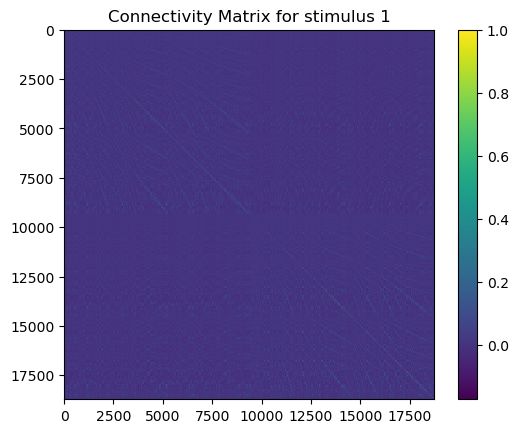

In [2]:
import numpy as np
import os.path as op
import matplotlib.pyplot as plt

# Example subject and stimulus
sub = 'All'
stim = '1'
group = '0'
arctanh = '' #_arctanh
ses = '1'

source_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/correlation_matrices.glmsingle'

# File path #'cm_av_ses-{ses}_fsav5_unfiltered_stimulus-{stimulus}_glmsingle_group-{i}.npy'
file_path = op.join(source_folder, f'cm_av_ses-{ses}_fsav5_unfiltered_stimulus-{stim}_glmsingle{arctanh}.npy') #_group-{group}

# Load the connectivity matrix
connectivity_matrix = np.load(file_path, allow_pickle=True)

# Print basic information
print(f"Shape: {connectivity_matrix.shape}") # 18715, 18715
print(f"Type: {type(connectivity_matrix)}")
print(connectivity_matrix)

# Visualize the matrix
plt.imshow(connectivity_matrix, cmap='viridis')
plt.colorbar()
plt.title(f'Connectivity Matrix for stimulus {stim}')
plt.show()

In [4]:
np.isnan(connectivity_matrix).sum()


np.int64(0)

In [ ]:
print(np.min(connectivity_matrix), np.max(connectivity_matrix))

# for group 0 stim 1 --> -0.16286875855979135 0.9534981145454143
# for stim 1 no group --> -0.1755429620350623 0.9764788884936941

-0.1755429620350623 0.9764788884936941


In [77]:
g_ref = np.load(op.join(bids_folder_matrices,'derivatives', 'gradients.glmsingle','sub-All', f'stimulus_{stimulus}', f'sub-All_gradients_space-fsaverag5_n10_stimulus_{stimulus}_betas.npy')) # same labeling_noParcel as cm_unfiltered
g_ref.shape

(10, 20484)

In [10]:
from brainspace.gradient import GradientMaps
from brainspace.utils.parcellation import map_to_labels
from my_utils import get_basic_mask
import numpy as np

source_folder = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk/derivatives/correlation_matrices.glmsingle'
bids_folder_reference = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/'
bids_folder_matrices = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk'

mask, labeling_noParcel = get_basic_mask()

sub = '01'
stimulus = '2'
#group = '1'
ses = '1'
arctanh = '' # _arctanh
kernel = 'None' # normalized_angle

n_components = 10 # reference gradient only has 3 components anyway... for better alignment one needs more components?! (according to Alam, 2022, L-R GM differences & cognition )

av_cm = np.load(op.join(source_folder, f'sub-{sub}_ses-1_stimulus-{stim}_betas_space-fsav5_transf.npy')) #_group-{group} #cm_av_ses-{ses}_fsav5_unfiltered_stimulus-{stimulus}_glmsingle{arctanh}.npy

target_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stimulus}')
if not op.exists(target_dir):
    os.makedirs(target_dir)

# load in reference gradient and apply same filter
g_ref = np.load(op.join(bids_folder_reference,'derivatives', 'gradients.glmsingle','sub-All', f'stimulus_{stimulus}', f'sub-All_gradients_space-fsaverag5_n10_stimulus_{stimulus}_betas{arctanh}.npy')) # same labeling_noParcel as cm_unfiltered
g_ref = g_ref[:, mask] #

# now perform embedding on cleaned data + alignment
print(f'start fitting gradintes now')
gm = GradientMaps(n_components=n_components, alignment='procrustes', approach='dm', kernel=None) # defaults: approach = 'dm', kernel = normalized_angle
gm.fit(av_cm,reference=g_ref.T)
print(f'finished stimulus_{stimulus}: gradients generated')

np.save(op.join(target_dir,f'sub-{sub}_lambdas_space-fsaverag5_n10{specification}_stimulus_{stimulus}_betas_kernel_{kernel}_transf.npy'), gm.lambdas_) # save all together _group-{group}
gm_= gm.gradients_.T 
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_gradients_space-fsaverag5_n10{specification}_stimulus_{stimulus}_betas_kernel_{kernel}_transf.npy'), grad) # save all together _group-{group}
gm_ = gm.aligned_.T
grad = [None] * n_components
for i, g in enumerate(gm_): # gm.gradients_.T
    grad[i] = map_to_labels(g, labeling_noParcel, mask=mask, fill=np.nan)
np.save(op.join(target_dir,f'sub-{sub}_g-aligned_space-fsaverag5_n10{specification}_stimulus_{stimulus}_betas_kernel_{kernel}_transf.npy'), grad) # save all together _group-{group}

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface


/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:164: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:164: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


start fitting gradintes now


/home/ubuntu/miniforge3/envs/pmd_env/lib/python3.10/site-packages/brainspace/gradient/embedding.py:70: UserWarning: Affinity is not symmetric. Making symmetric.
  warnings.warn('Affinity is not symmetric. Making symmetric.')


finished stimulus_2: gradients generated


In [6]:
#g_ref.shape
av_cm.shape

(18715, 18715)

In [15]:
bids_folder_matrices = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-numrisk'

specification = '' # align_spec = '_align-procrustes'

sub = 'All'
stimuli = ['1', '2'] #
#group = '0'
spec = 'g-aligned'  # gradients
kernel = 'None' # normalized_angle

grad = {'1': [],
        '2': []}

for stim in stimuli:
    target_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim}') #, 

    grad[stim] = np.load(op.join(target_dir,f'sub-{sub}_{spec}_space-fsaverag5_n10{specification}_stimulus_{stim}_betas_kernel_{kernel}.npy')) # _group-{group}

/tmp/ipykernel_409445/2202559583.py:18: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right


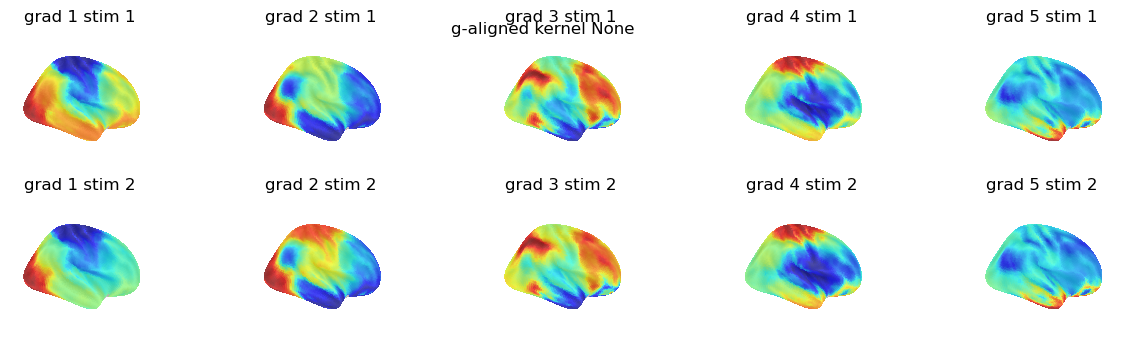

In [16]:
# plotting gradients

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from  nilearn.datasets import fetch_surf_fsaverage
fsaverage = fetch_surf_fsaverage() # default 5

side_view = 'medial'
cmap = 'jet'
n_comp = 5

figure, axes = plt.subplots(nrows=2, ncols=n_comp,figsize = (15,4), subplot_kw=dict(projection='3d'))

for j, stim in enumerate(stimuli):
    for i in range(0,n_comp):
        gm = np.split(grad[stim][i],2) # for i, hemi in enumerate([‘L’, ‘R’]): --> left first
        gm_r = gm[1]
        nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right
                    view= side_view,cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
                    bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7 ,axes=axes[j, i]) #
        axes[j, i].set(title=f'grad {i+1} stim {stim}')
    figure.suptitle(f'{spec} kernel {kernel}', y=0.9)

In [ ]:
stim

'2'

/tmp/ipykernel_399276/1480812903.py:30: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nplt.plot_surf(


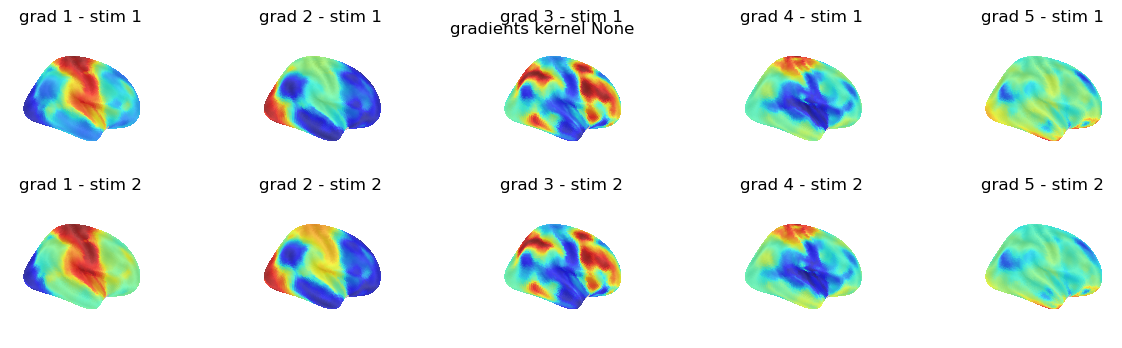

In [66]:
# code to flip grad 1 for stim_1 

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from nilearn.datasets import fetch_surf_fsaverage

fsaverage = fetch_surf_fsaverage()  # default fsaverage5

side_view = 'medial'
cmap = 'jet'
n_comp = 5

figure, axes = plt.subplots(nrows=2, ncols=n_comp, figsize=(15, 4), subplot_kw=dict(projection='3d'))

for j, stim in enumerate(stimuli):
    for i in range(0, n_comp):
        # Flip grad 1 values if i == 0
        if stim == '2':
            grad_to_plot = -grad[stim][i] if i == 0 else grad[stim][i]
        else:
            grad_to_plot = grad[stim][i]
        
        

        # Split into left and right hemispheres
        gm = np.split(grad_to_plot, 2)  # Left first, then right
        gm_r = gm[1]
        
        # Plot the right hemisphere
        nplt.plot_surf(
            surf_mesh=fsaverage.infl_right, surf_map=gm_r,  # infl_right or pial_right
            view=side_view, cmap=cmap, colorbar=False,
            bg_map=fsaverage.sulc_right, bg_on_data=True, darkness=0.7, axes=axes[j, i]
        )
        axes[j, i].set(title=f'grad {i+1} - stim {stim}')
    figure.suptitle(f'{spec} kernel {kernel}', y=0.9)

plt.show()

In [4]:
bids_folder_matrices = '/mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk'

specification = '' # align_spec = '_align-procrustes'

sub = 'All'
stim = 'both'
groups = ['0', '1']
spec = 'gradients'  #g-aligned
grad = {'0': [],
        '1': []}

for group in groups:
    target_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim}')

    grad[group] = np.load(op.join(target_dir,f'sub-{sub}_{spec}_space-fsaverag5_n10{specification}_stimulus_{stim}_group-{group}_betas.npy'))

/tmp/ipykernel_337613/1246392348.py:18: DeprecationWarning: The `darkness` parameter will be deprecated in release 0.13. We recommend setting `darkness` to None
  nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right


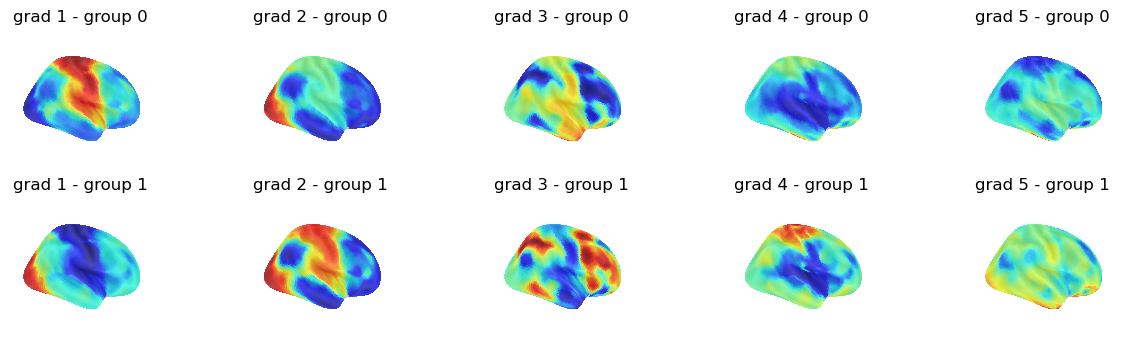

In [5]:
# plotting gradients

import nilearn.plotting as nplt
import matplotlib.pyplot as plt
from  nilearn.datasets import fetch_surf_fsaverage
fsaverage = fetch_surf_fsaverage() # default 5

side_view = 'medial'
cmap = 'jet'
n_comp = 5

figure, axes = plt.subplots(nrows=2, ncols=n_comp,figsize = (15,4), subplot_kw=dict(projection='3d'))

for j, group in enumerate(groups):
    for i in range(0,n_comp):
        gm = np.split(grad[group][i],2) # for i, hemi in enumerate([‘L’, ‘R’]): --> left first
        gm_r = gm[1]
        nplt.plot_surf(surf_mesh= fsaverage.infl_right, surf_map= gm_r, # infl_right # pial_right
                    view= side_view,cmap=cmap, colorbar=False,  # sub-{sub}, title=f’grad {i+1}‘,
                    bg_map=fsaverage.sulc_right, bg_on_data=True,darkness=0.7 ,axes=axes[j, i]) #
        axes[j, i].set(title=f'grad {i+1} - group {group}')
    #figure.suptitle(f'group {group} - {spec}', y=0.9)

In [28]:
# plot lambdas

from kneed import KneeLocator #  knee point is the point of maximum curvature.

sub = 'All'
n_comp=10
stimuli_types = ['1', '2']

# Loop through each stimulus
for stimulus in stimuli_types:
    print(f"Processing {stimulus}...")

    fn_lambdas = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stimulus}',f'sub-{sub}_lambdas_space-fsaverag5_n10{specification}_stimulus_{stimulus}_betas.npy')
    lambdas = np.load(fn_lambdas)
    
    # Find the knee point
    kneedle = KneeLocator(x=range(1, len(lambdas) + 1), y=lambdas, S=1.0, curve="convex", direction="decreasing")
    
    # Plot the knee
    plt.figure()
    kneedle.plot_knee()
    plt.title(f"Knee Plot for {stimulus}")
    plt.xlabel("Component")
    plt.ylabel("Lambda")

    # Save the plot
    output_plot_path = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stimulus}', f'sub-{sub}_knee_plot_{stimulus}_betas.png')
    plt.savefig(output_plot_path)
    plt.close()
    print(f"Saved knee plot for {stimulus} at {output_plot_path}")

Processing 1...
Saved knee plot for 1 at /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/sub-All/stimulus_1/sub-All_knee_plot_1_betas.png
Processing 2...
Saved knee plot for 2 at /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/sub-All/stimulus_2/sub-All_knee_plot_2_betas.png


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

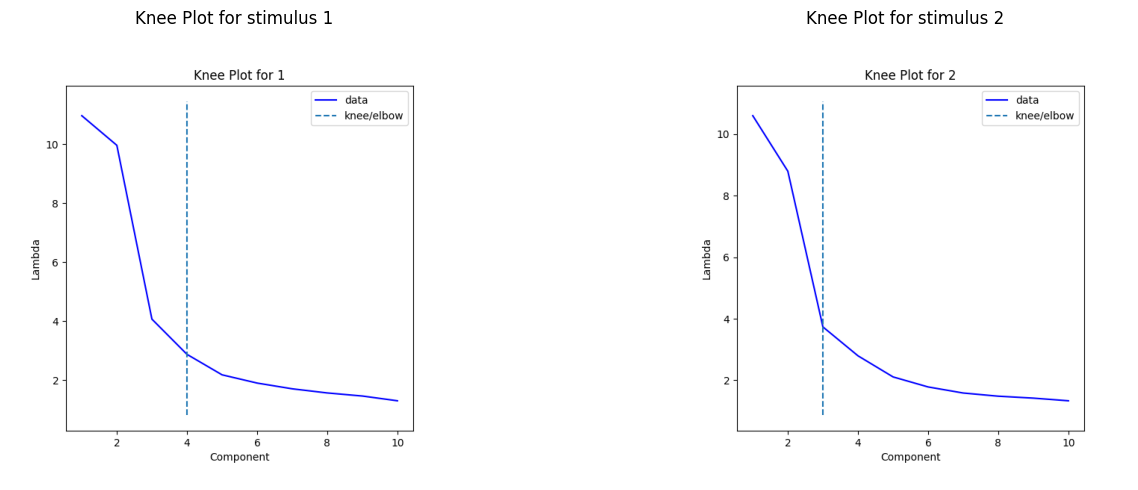

In [30]:
import matplotlib.pyplot as plt
import os.path as op

# Parameters
sub = 'All'
stimuli_types = ['1', '2']

# Initialize figure for side-by-side visualization
fig, axes = plt.subplots(1, len(stimuli_types), figsize=(15, 5))  # 1 row, 3 columns

# Loop through each stimulus to load and display the saved plots
for i, stimulus in enumerate(stimuli_types):
    # File path to the saved plot
    plot_path = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stimulus}', f'sub-{sub}_knee_plot_{stimulus}_betas.png')
    
    # Load and display the saved plot
    img = plt.imread(plot_path)
    ax = axes[i]
    ax.imshow(img)
    ax.axis('off')  # Turn off axes for better visualization
    ax.set_title(f"Knee Plot for stimulus {stimulus}")

# Adjust layout and show the combined visualization
plt.tight_layout()
plt.show()

Processing comparison: stimulus 1 vs stimulus 2...
Correlation Matrix for 1 vs 2:
[[0.99603095 0.15259717 0.00519985 0.49257325 0.11525964]
 [0.15392174 0.99535514 0.47255909 0.19236825 0.03584013]
 [0.01908942 0.49555236 0.98899353 0.2559499  0.23989742]
 [0.48777819 0.203557   0.2342287  0.99486972 0.31288861]
 [0.10392541 0.02303733 0.23026164 0.28952345 0.99218454]]


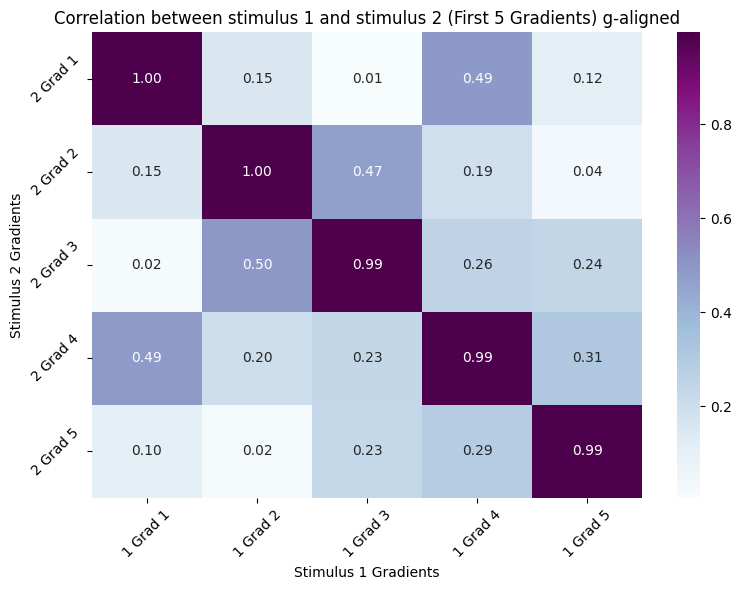

In [34]:
# plot correlation matrix checking similarity between stim 1 and stim 2, stim 1 and remaining, stim 2 and remaining

from neuromaps.stats import compare_images
import numpy as np
import os.path as op
import seaborn as sns
import matplotlib.pyplot as plt

# Parameters
sub = 'All'
spec = 'g-aligned'  # gradients
stimuli_pairs = [
    ('1', '2')
]

n_gradients_to_compare = 5  # Compare only the first 5 gradients

# Loop over stimulus pairs and calculate correlations
for stim1, stim2 in stimuli_pairs:
    print(f"Processing comparison: stimulus {stim1} vs stimulus {stim2}...")
    
    # File paths to the gradient files
    grad1_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim1}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stim1}_betas.npy')
    grad2_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim2}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stim2}_betas.npy')
    
    # Load the gradients
    grad1 = np.load(grad1_file)[:n_gradients_to_compare]  # Load first 5 gradients
    grad2 = np.load(grad2_file)[:n_gradients_to_compare]  # Load first 5 gradients
    
    # Initialize correlation matrix for this pair
    correlation_matrix = np.zeros((n_gradients_to_compare, n_gradients_to_compare))
    
    # Compute correlations between gradients
    for i in range(n_gradients_to_compare):
        for j in range(n_gradients_to_compare):
            corrcoef = compare_images(grad1[i], grad2[j], metric='pearsonr')
            correlation_matrix[i, j] = np.abs(corrcoef)
    
    # Print the correlation matrix
    print(f"Correlation Matrix for {stim1} vs {stim2}:")
    print(correlation_matrix)
    
    # Plot the correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="BuPu",
                xticklabels=[f'{stim1} Grad {i+1}' for i in range(n_gradients_to_compare)],
                yticklabels=[f'{stim2} Grad {i+1}' for i in range(n_gradients_to_compare)])
    plt.title(f"Correlation between stimulus {stim1} and stimulus {stim2} (First {n_gradients_to_compare} Gradients) {spec}")
    plt.xlabel(f"Stimulus {stim1} Gradients")
    plt.ylabel(f"Stimulus {stim2} Gradients")
    
    # Rotate the x-axis labels
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [15]:
from my_utils import get_glasser_parcels, get_glasser_CAatlas_mapping
import os
import hcp_utils as hcp
from matplotlib.colors import ListedColormap
import seaborn as sns

rgb = np.array(list(hcp.ca_network['rgba'].values())[1:])
ca_cmap = ListedColormap(np.vstack(([1, 1, 1, 1], rgb)), 'custom_colormap') # add white infront, 0=unknown, 1-12 actual labels

# Update the function to use the correct path
mask_glasser, labeling_glasser = get_glasser_parcels(space='fsaverage5')
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

from brainspace.utils.parcellation import map_to_labels
caNets_fsav5_mapping = map_to_labels(
    glasser_CAatlas_mapping['ca_network'].values,
    labeling_glasser,
    mask=mask_glasser
)

In [16]:
CAatlas_names['Network Name']

Label Number
1                  Visual1
2                  Visual2
3              Somatomotor
4        Cingulo-Opercular
5         Dorsal-attention
6                 Language
7           Frontoparietal
8                 Auditory
9                  Default
10    Posterior-Multimodal
11      Ventral-Multimodal
12        Orbito-Affective
Name: Network Name, dtype: object

In [5]:
print(CAatlas_names)

                      Network Name
Label Number                      
1                          Visual1
2                          Visual2
3                      Somatomotor
4                Cingulo-Opercular
5                 Dorsal-attention
6                         Language
7                   Frontoparietal
8                         Auditory
9                          Default
10            Posterior-Multimodal
11              Ventral-Multimodal
12                Orbito-Affective


In [ ]:
# plot gradients with assigning the precision functional mapping maps

map_dir = "/home/ubuntu/data/precis_map.glm/maps/"

stimuli = ['1', '2']
precis_map = {}

for stim in stimuli:
    precis_map[stim] = np.load(op.join(map_dir, f"sub-All_ses-1_task-magjudge_stim-{stim}_consensusMapping_threshs-0.03-0.04-0.05-0.1-0.2-0.4.npy"))


In [22]:
caNets_fsav5_mapping = caNets_fsav5_mapping[mask]

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface
Processing 1...


/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:164: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:164: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


Processing 2...


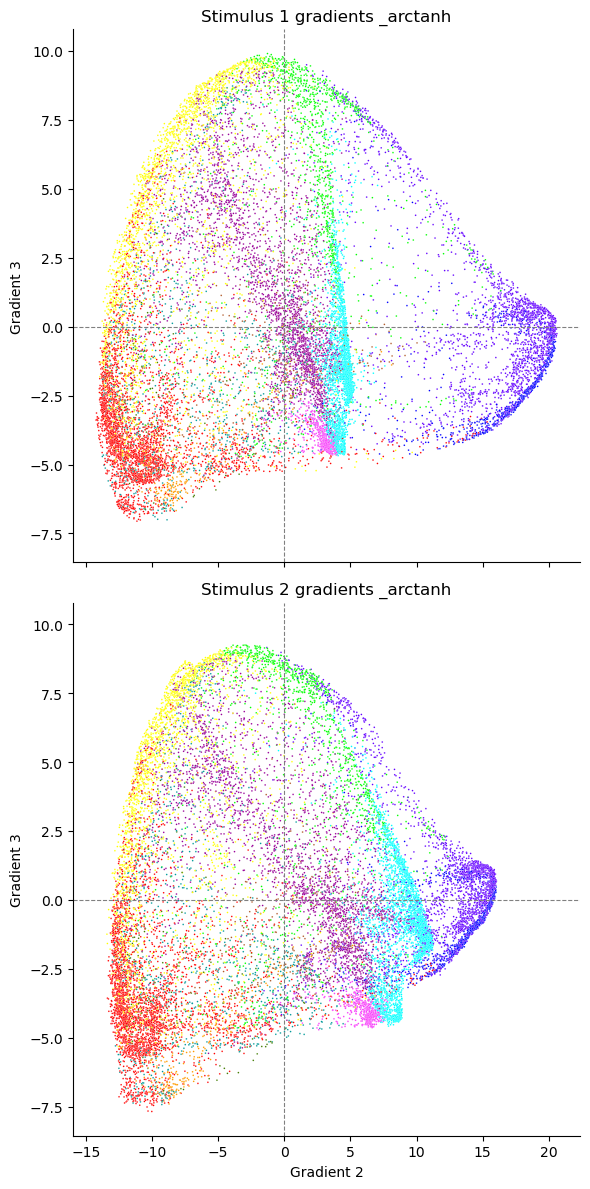

In [28]:
# remember to load bids_folder definition

import numpy as np
import os.path as op
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from my_utils import get_basic_mask

mask, labeling_noParcel = get_basic_mask()

sub = 'All'
stimuli_types = ['1', '2']
spec = 'gradients'  # g-aligned
arctanh = '_arctanh' #''
network_map = caNets_fsav5_mapping # needs to be masked!! # precis_map

# Create a dictionary mapping network names to colors
network_colors = {name: color for name, color in zip(CAatlas_names['Network Name'], ca_cmap.colors[1:])}

# Placeholder for results
correlation_results = {}

# Create subplots for each stimulus
fig, axs = plt.subplots(len(stimuli_types), 1, figsize=(6, 12), sharex=True, sharey=True)



for i, stimulus in enumerate(stimuli_types):  # Use enumerate to get the index (i) and stimulus name
    print(f'Processing {stimulus}...')
    
    try:
        # Load the combined gradient matrix for the current stimulus
        gradients = np.load(op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', 
                                     f'sub-{sub}', f'stimulus_{stimulus}', 
                                     f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stimulus}_betas{arctanh}.npy'))

        # Extract the first two rows (Gradient 1 and Gradient 2)
        grad1 = -gradients[0, :][mask]  # First row: Gradient 1, need to flip this gradient
        grad2 = gradients[1, :][mask]  # Second row: Gradient 2
        grad3 = gradients[2, :][mask]  # Second row: Gradient 3

        # Create a DataFrame for plotting
        df = pd.DataFrame({
            'Gradient 1': grad1,
            'Gradient 2': grad2,
            'Gradient 3': grad3,
            'ca_network': network_map # [stim]  # Map network indices to vertices
        })

        # Map network names to the ca_network column
        df['ca_network_name'] = df['ca_network'].map(CAatlas_names['Network Name'])

        # Scatter plot of Gradient 1 vs Gradient 2
        sns.scatterplot(data=df, x='Gradient 2', y='Gradient 3', hue='ca_network_name', 
                        palette=network_colors, s=1.4, legend=False, ax=axs[i])
        axs[i].set(title=f'Stimulus {stimulus} {spec} {arctanh}', xlabel='Gradient 2', ylabel='Gradient 3') # mapping to beta derived precision mapping map
        axs[i].axhline(0, color='gray', linestyle='--', linewidth=0.8)
        axs[i].axvline(0, color='gray', linestyle='--', linewidth=0.8)

    except Exception as e:
        print(f'Failed to process {stimulus}: {e}')

# Adjust layout and remove spines
plt.tight_layout()
sns.despine()
plt.show()

Processing comparison: Stimulus 1 vs stimulus reference_grad...
Correlation Matrix for 1 vs reference_grad:
[[0.84987484 0.42559056 0.05010926 0.24661903 0.03502965]
 [0.30446613 0.84149631 0.2583851  0.29463453 0.07136854]
 [0.21876794 0.13506821 0.21151142 0.59020044 0.69098061]
 [0.16545882 0.10132641 0.76452934 0.42850219 0.22247237]
 [0.24879068 0.19035171 0.32329036 0.35419297 0.52642362]]


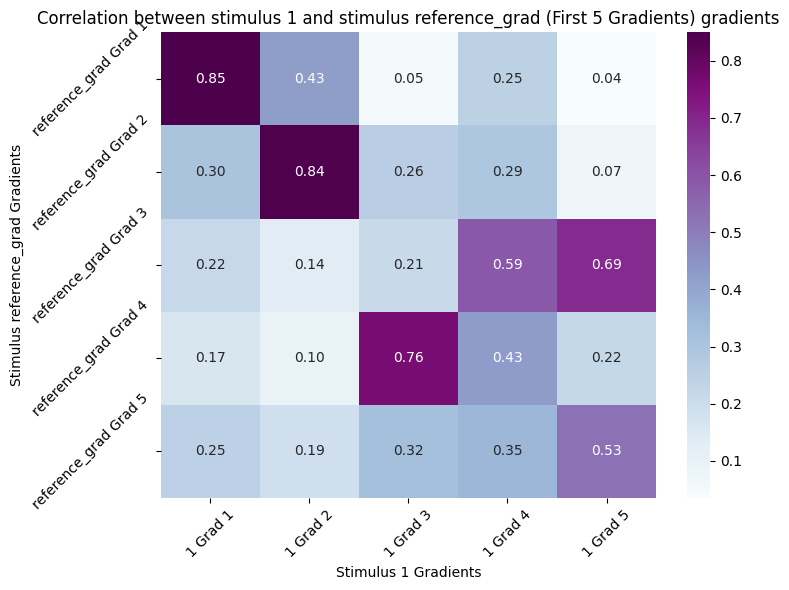

Processing comparison: Stimulus 2 vs stimulus reference_grad...
Correlation Matrix for 2 vs reference_grad:
[[0.83548761 0.45074435 0.1045663  0.24087861 0.0643412 ]
 [0.30895894 0.83865827 0.23889649 0.32701824 0.01779364]
 [0.23291336 0.21280007 0.24131007 0.6573403  0.59539173]
 [0.1525107  0.1243084  0.80398921 0.40335502 0.20028271]
 [0.2651612  0.20497583 0.36804236 0.35641503 0.63312875]]


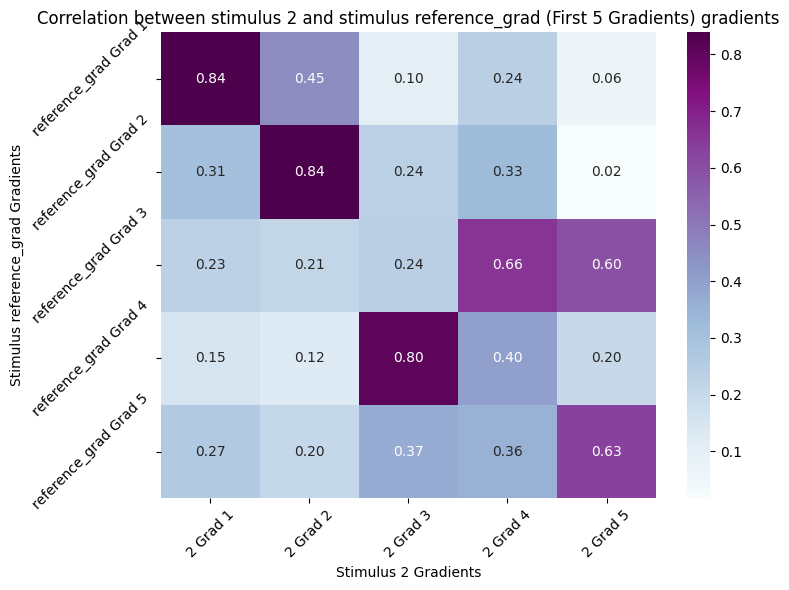

In [40]:
# correlation matrices between unaligned gradients and whole task gradients

from neuromaps.stats import compare_images
import numpy as np
import os.path as op
import seaborn as sns
import matplotlib.pyplot as plt


# Parameters
sub = 'All'
spec = 'gradients' 
stimuli_pairs = [
    ('1', 'reference_grad'),
    ('2', 'reference_grad')
]

n_gradients_to_compare = 5  # Compare only the first 5 gradients

# Loop over stimulus pairs and calculate correlations
for stim1, stim2 in stimuli_pairs:
    print(f"Processing comparison: Stimulus {stim1} vs stimulus {stim2}...")
    
    # File paths to the gradient files
    grad1_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'sub-{sub}', f'stimulus_{stim1}', f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stim1}_betas.npy')
    grad2_file = op.join(bids_folder_subjects,'derivatives', 'gradients','sub-All/sub-All_gradients_N-10.npy')
    
    # Load the gradients
    grad1 = np.load(grad1_file)[:n_gradients_to_compare]  # Load first 5 gradients
    grad2 = np.load(grad2_file)[:n_gradients_to_compare]  # Load first 5 gradients

    # Initialize correlation matrix for this pair
    correlation_matrix = np.zeros((n_gradients_to_compare, n_gradients_to_compare))
    
    # Compute correlations between gradients
    for i in range(n_gradients_to_compare):
        for j in range(n_gradients_to_compare):
            corrcoef = compare_images(grad1[i], grad2[j], metric='pearsonr')
            correlation_matrix[i, j] = np.abs(corrcoef)
    
    # Print the correlation matrix
    print(f"Correlation Matrix for {stim1} vs {stim2}:")
    print(correlation_matrix)
    
    # Plot the correlation matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="BuPu",
                xticklabels=[f'{stim1} Grad {i+1}' for i in range(n_gradients_to_compare)],
                yticklabels=[f'{stim2} Grad {i+1}' for i in range(n_gradients_to_compare)])
    plt.title(f"Correlation between stimulus {stim1} and stimulus {stim2} (First {n_gradients_to_compare} Gradients) {spec}")
    plt.xlabel(f"Stimulus {stim1} Gradients")
    plt.ylabel(f"Stimulus {stim2} Gradients")
    
    # Rotate the x-axis labels
    plt.xticks(rotation=45)
    plt.yticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np

network_path = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk/derivatives/networks_infomap_full/sub-average_consensusMapping_confspec-36Pscrub3BPfilter.npy'
prec_network = np.load(network_path)

In [ ]:
network_file = caNets_fsav5_mapping

In [22]:
# two-sample t-tests between network positions of stim 1 and stim 2 on the first gradient (because auditory network has this shift)

import numpy as np
import os
import os.path as op
import pandas as pd
from my_utils import get_basic_mask

sub = 'All'
stimuli_types = ['1', '2']
spec = 'gradients' #g-aligned
network = 'CAatlas' # precismap-timeseries

network_file = caNets_fsav5_mapping # prec_network

mask, labeling_noParcel = get_basic_mask()

# Directory to save the DataFrames
output_dir = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle')

for stimulus in stimuli_types:
    print(f'Processing {stimulus}...')
    
    try:
        # Load the combined gradient matrix for the current stimulus
        gradients = np.load(op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', 
                                     f'sub-{sub}', f'stimulus_{stimulus}', 
                                     f'sub-{sub}_{spec}_space-fsaverag5_n10_stimulus_{stimulus}_betas.npy'))

        # Extract the gradient corresponding rows
        grad1 = -gradients[0, :][mask]  # First row: Gradient 1
        grad2 = gradients[1, :][mask]  # Second row: Gradient 2
        grad3 = gradients[2, :][mask]  # Third row: Gradient 3

        # Create a DataFrame
        df = pd.DataFrame({
            'Gradient 1': grad1,
            'Gradient 2': grad2,
            'Gradient 3': grad3,
            'ca_network': network_file  # Map network indices to vertices
        })

        # Map network names to the ca_network column
        df['ca_network_name'] = df['ca_network'].map(CAatlas_names['Network Name'])

        # Save the DataFrame to a CSV file
        output_file = op.join(output_dir, f'stim-{stimulus}_dataframe_network-{network}.csv')
        df.to_csv(output_file, index=False)
        print(f'Saved DataFrame for {stimulus} to {output_file}')

    except Exception as e:
        print(f'Failed to process {stimulus}: {e}')

[fetch_atlas_surf_destrieux] Dataset found in /home/ubuntu/nilearn_data/destrieux_surface
Processing 1...


/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:164: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()
/home/ubuntu/git/parietal_patterns/sophie/my_utils.py:164: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index    name
     0 Unknown

  atlas = datasets.fetch_atlas_surf_destrieux()


Saved DataFrame for 1 to /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/stim-1_dataframe_network-CAatlas.csv
Processing 2...
Saved DataFrame for 2 to /mnt_AdaBD_largefiles/Data/SMILE_DATA/DNumRisk/ds-dnumrisk/derivatives/gradients.glmsingle/stim-2_dataframe_network-CAatlas.csv


In [23]:
# t-test to compare network positions between stimulus_1 and stimulus_2

import pandas as pd
from scipy.stats import ttest_ind
import os.path as op

# Load the saved DataFrames for stimulus_1 and stimulus_2
stim1_df = pd.read_csv(op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'stim-1_dataframe_network-{network}.csv'))
stim2_df = pd.read_csv(op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'stim-2_dataframe_network-{network}.csv'))

# Initialize a dictionary to store t-test results
t_test_results = {}

# Initialize a list to document rows with NaN values
nan_rows_log = []
gradients = ['1', '2', '3']

for grad in gradients:

    # Perform two-sample t-tests for each network
    for network in stim1_df['ca_network_name'].unique():
        # Filter data for the current network and convert to DataFrame
        stim1_values = stim1_df[stim1_df['ca_network_name'] == network][[f'Gradient {grad}']]
        stim2_values = stim2_df[stim2_df['ca_network_name'] == network][[f'Gradient {grad}']]
        
        # Identify rows with NaN values in either DataFrame
        stim1_nan_rows = stim1_values[stim1_values.isna().any(axis=1)].index.tolist()
        stim2_nan_rows = stim2_values[stim2_values.isna().any(axis=1)].index.tolist()
        
        # Log rows with NaN values
        if stim1_nan_rows:
            nan_rows_log.append({'network': network, 'dataframe': 'stimulus_1', 'rows': stim1_nan_rows})
        if stim2_nan_rows:
            nan_rows_log.append({'network': network, 'dataframe': 'stimulus_2', 'rows': stim2_nan_rows})

        # Drop rows with NaN values
        stim1_values = stim1_values.dropna()
        stim2_values = stim2_values.dropna()

        # Perform the t-test if both groups have sufficient data
        if len(stim1_values) > 1 and len(stim2_values) > 1:
            t_stat, p_value = ttest_ind(stim1_values[f'Gradient {grad}'], stim2_values[f'Gradient {grad}'], equal_var=False)
        else:
            t_stat, p_value = float('nan'), float('nan')

        # Perform a two-sample t-test
        t_stat, p_value = ttest_ind(stim1_values, stim2_values, equal_var=False)  # Welch's t-test
        
        # Store the results
        t_test_results[network] = {'t_stat': t_stat, 'p_value': p_value}

    # Convert results to a DataFrame for easier visualization
    t_test_results_df = pd.DataFrame.from_dict(t_test_results, orient='index')
    t_test_results_df.index.name = 'Network'
    t_test_results_df.reset_index(inplace=True)

    # Add a column to indicate significance (e.g., p < 0.05)
    t_test_results_df['Significant'] = t_test_results_df['p_value'] < 0.0001

    # Print the results
    print(f"results {t_test_results_df} for grad {grad}")

    # Save the results to a CSV file
    output_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f't_test_results_stim_1_stim_2_grad{grad}_network-{network}.csv')
    t_test_results_df.to_csv(output_file, index=False)
    print(f'T-test results saved to {output_file}')

    # Save the log of NaN rows to a CSV file
    nan_log_file = op.join(bids_folder_matrices, 'derivatives', 'gradients.glmsingle', f'nan_rows_log_grad{grad}_network-{network}.csv')
    pd.DataFrame(nan_rows_log).to_csv(nan_log_file, index=False)
    print(f'NaN rows log saved to {nan_log_file}')

/home/ubuntu/miniforge3/envs/pmd_env/lib/python3.10/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)
/home/ubuntu/miniforge3/envs/pmd_env/lib/python3.10/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


results                  Network                  t_stat                   p_value  \
0            Somatomotor    [30.305147879401094]   [6.31899951814343e-187]   
1                Visual2   [0.13991313142110723]      [0.8887352142998439]   
2      Cingulo-Opercular   [-2.8913257308093683]   [0.0038505940120169193]   
3         Frontoparietal    [-6.806045382143161]  [1.1196400057727756e-11]   
4                Visual1   [-0.5421993164362523]      [0.5877682832406624]   
5               Language    [-1.663462209622578]     [0.09636849966544456]   
6     Ventral-Multimodal   [-2.8681792159998767]    [0.004271907240583682]   
7       Dorsal-attention   [-1.4529822638327152]     [0.14635086224161253]   
8                Default   [-2.6414693091801396]    [0.008273723938094862]   
9                    NaN                   [nan]                     [nan]   
10              Auditory   [-1.8145989866826662]     [0.06986946389552011]   
11  Posterior-Multimodal  [-0.08257619275005554]      [0

/home/ubuntu/miniforge3/envs/pmd_env/lib/python3.10/site-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: All axis-slices of one or more sample arguments are too small; all elements of returned arrays will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


/tmp/ipykernel_296099/4100831174.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_296099/4100831174.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_296099/4100831174.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_296099/4100831174.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/tmp/ipykernel_296099/4100831174.py:15: UserWarning: No artists with labels found to put in legend. 

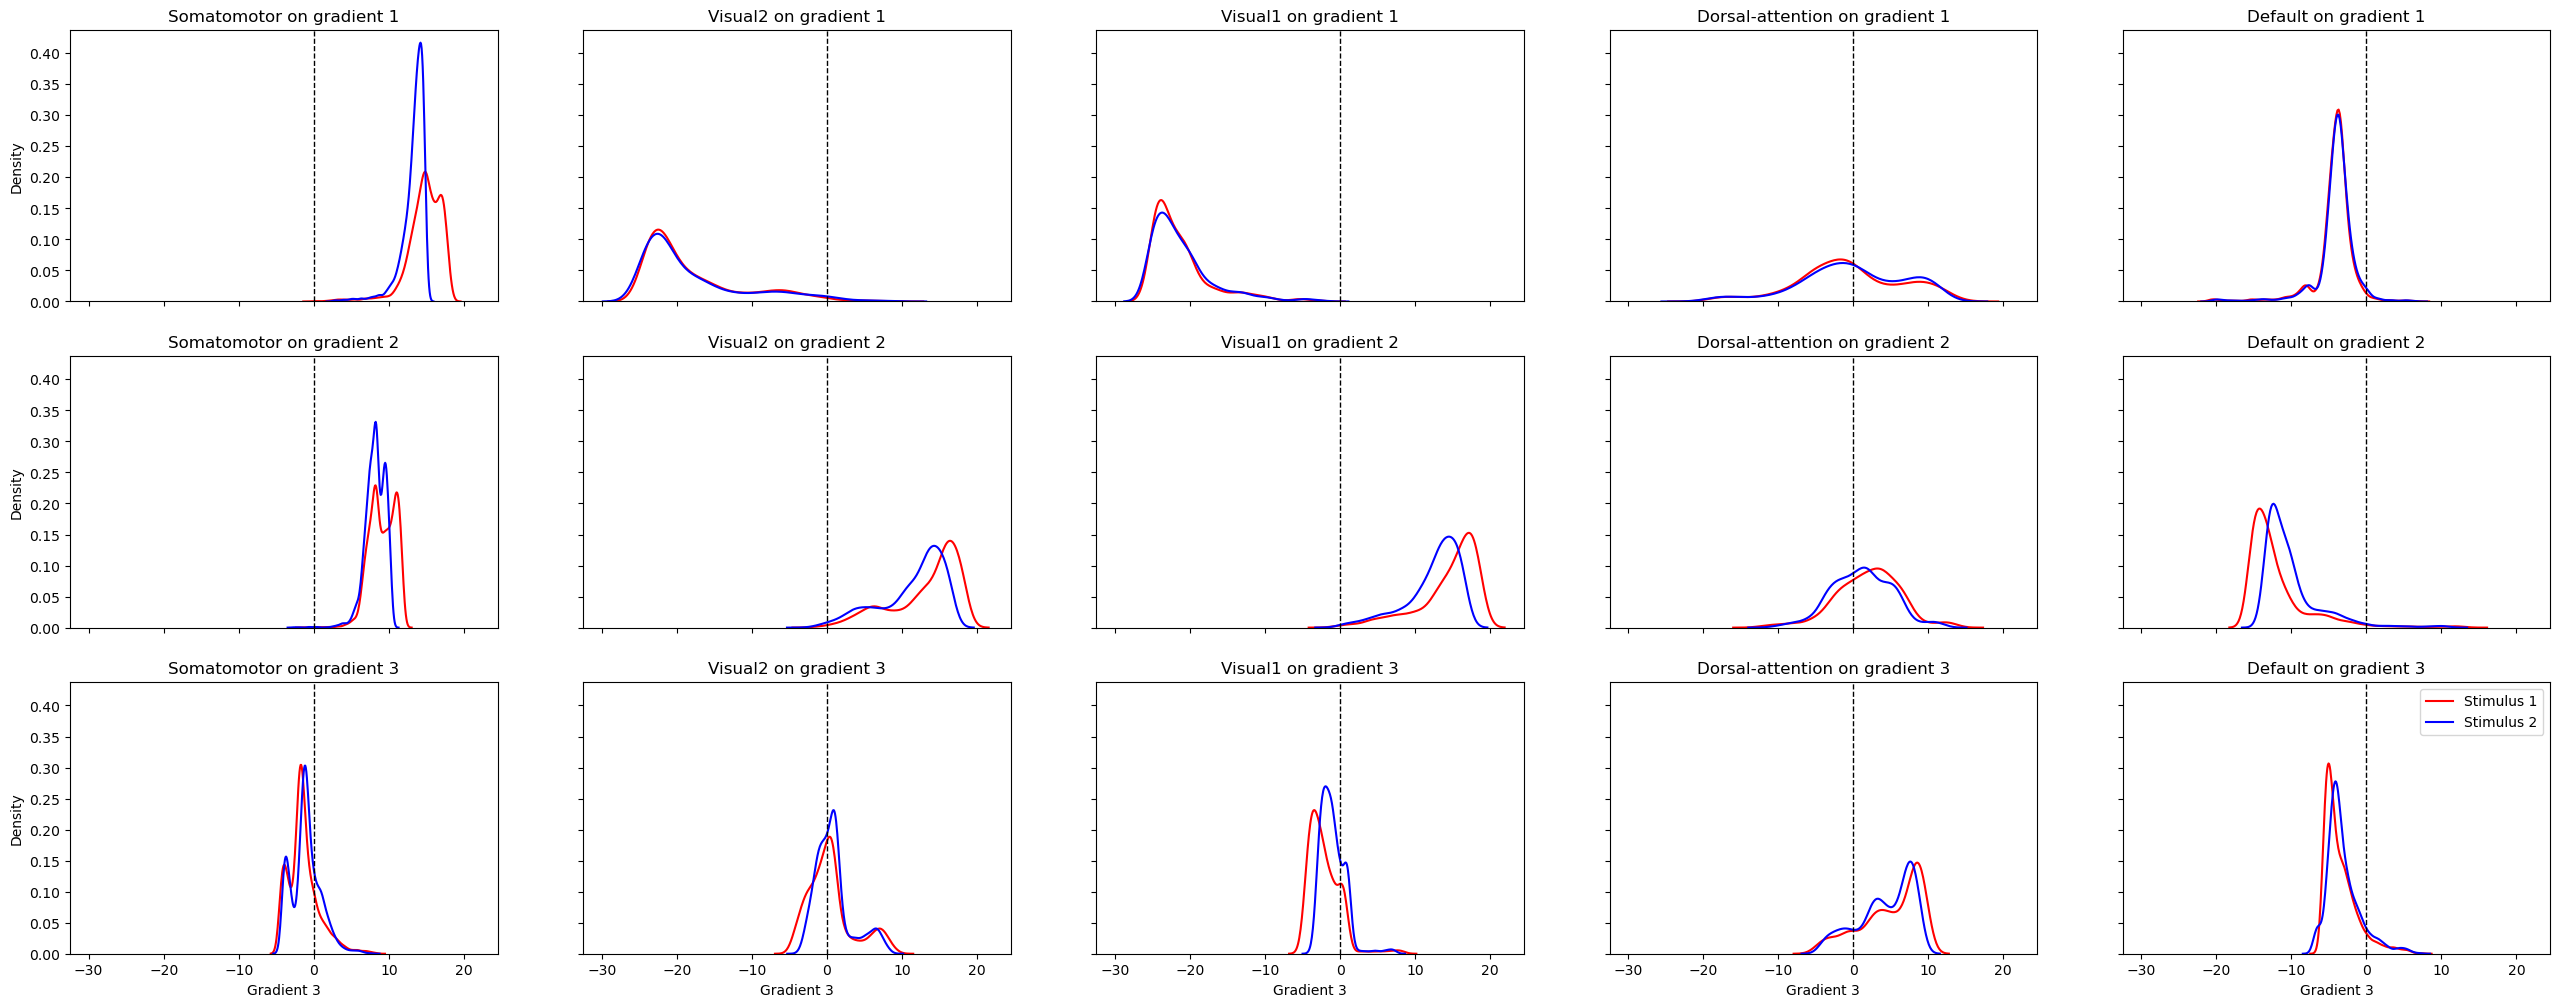

In [25]:
fig, axes = plt.subplots(3, 5, figsize=(32, 12), sharex=True, sharey=True)

networks = ['Somatomotor','Visual2',  'Visual1', 'Dorsal-attention', 'Default']
gradients = ['1', '2', '3']

for i, grad in enumerate(gradients):

    for j, net in enumerate(networks):
        ax = axes[i, j]

        sns.kdeplot(stim1_df[stim1_df['ca_network_name'] == net][f'Gradient {grad}'], label='Stimulus 1', color='red', ax=axes[i,j])
        sns.kdeplot(stim2_df[stim2_df['ca_network_name'] == net][f'Gradient {grad}'], label='Stimulus 2', color='blue', ax=axes[i,j])
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        axes[i,j].set(title=f'{net} on gradient {grad}')
        plt.legend()
        
plt.show()